In [22]:
import os
import librosa
import numpy as np
import torch
import torchaudio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import Wav2Vec2Model, Wav2Vec2Processor
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tqdm import tqdm

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
data_dir = '/content/drive/MyDrive/dl4m_final/MC_vocals'

In [7]:
# Load data

def load_data(folder_path):

    X, y = [], []
    label_map = {"Mandarin": 0, "Cantonese": 1}

    for label_folder in os.listdir(folder_path):
        label_path = os.path.join(folder_path, label_folder)
        if not os.path.isdir(label_path):
            continue

        label = label_map.get(label_folder, None)
        if label is None:
            print(f"Warning: Unknown folder {label_folder}, skipped.")
            continue

        for file in os.listdir(label_path):
            if file.endswith(".wav"):
                file_path = os.path.join(label_path, file)
                audio, sr = librosa.load(file_path, sr=16000)
                X.append(audio)
                y.append(label)

    return X, y

In [8]:
# Data augmentation

def speed_perturb(audio, speed_rate):

    return librosa.resample(audio, orig_sr=16000, target_sr=int(16000 * speed_rate))

def augment_audio(audio):

    aug_audio = []

    # speed perturbation
    speed = np.random.uniform(0.9, 1.1)
    aug_audio.append(speed_perturb(audio, speed))

    # pitch shifting
    pitch = np.random.uniform(-1, 1)
    aug_audio.append(librosa.effects.pitch_shift(audio, sr=16000, n_steps=pitch))

    # add noise
    noise = np.random.randn(len(audio))
    aug_audio.append(audio + 0.003 * noise)

    # volume scaling
    gain = np.random.uniform(0.8, 1.2)
    aug_audio.append(np.clip(audio * gain, -1.0, 1.0))

    return aug_audio

def augment_audio_data(X, y):

    X_aug, y_aug = [], []

    for audio, label in zip(X, y):
        augmented = augment_audio(audio)
        X_aug.extend(augmented)
        y_aug.extend([label] * len(augmented))

    X_aug.extend(X)
    y_aug.extend(y)

    return X_aug, y_aug

In [9]:
# Wav2Vec2 Feature Extraction

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
wav2vec2_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")
wav2vec2_model.eval()

def extract_wav2vec2_features(audio):

    inputs = processor(audio, sampling_rate=16000, return_tensors="pt", padding=True)

    with torch.no_grad():
        outputs = wav2vec2_model(**inputs)

    hidden_states = outputs.last_hidden_state
    feature = torch.mean(hidden_states, dim=1).squeeze(0)

    return feature.numpy()

def prepare_features(X):

    features = []

    for audio in X:
        feature = extract_wav2vec2_features(audio)
        features.append(feature)

    return np.array(features)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [16]:
def dense_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [30]:
# Load dataset
data_dir = '/content/drive/MyDrive/dl4m_final/MC_vocals'
X, y = load_data(data_dir)

# Feature extraction
X_features = []
y_features = []

for audio, label in tqdm(list(zip(X, y)), total=len(X)):
    audio = audio[:16000 * 15]

    augmented_audios = augment_audio(audio)
    for aug_audio in augmented_audios:
        feature = extract_wav2vec2_features(aug_audio)
        X_features.append(feature)
        y_features.append(label)

    feature_orig = extract_wav2vec2_features(audio)
    X_features.append(feature_orig)
    y_features.append(label)

X_features = np.array(X_features)
y_features = np.array(y_features)


# Split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_features, y_features, test_size=0.2, stratify=y_features, random_state=1)

100%|██████████| 800/800 [40:28<00:00,  3.04s/it]


In [31]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (3200, 768)
y_train shape: (3200,)


In [32]:
# Build model
model = dense_model(input_shape=(X_features.shape[1],))
model.summary()

earlystop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_dense_model.h5', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[earlystop, checkpoint]
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,753 (417.00 KB)

 Trainable params: 106,753 (417.00 KB)

 Non-trainable params: 0 (0.00 B)

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7929 - loss: 0.4531 - val_accuracy: 0.8000 - val_loss: 0.4083
Epoch 11/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7969 - loss: 0.4270 - val_accuracy: 0.7875 - val_loss: 0.4350
Epoch 12/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7923 - loss: 0.4393 - val_accuracy: 0.7638 - val_loss: 0.4541
Epoch 13/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7875 - loss: 0.4493 - val_accuracy: 0.7713 - val_loss: 0.4627
Epoch 14/20
 78/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7808 - loss: 0.4518

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7807 - loss: 0.4507 - val_accuracy: 0.8037 - val_loss: 0.3963
Epoch 15/20
 78/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7837 - loss: 0.4408

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7860 - loss: 0.4399 - val_accuracy: 0.8225 - val_loss: 0.3949
Epoch 16/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7842 - loss: 0.4507 - val_accuracy: 0.8087 - val_loss: 0.4070
Epoch 17/20
 79/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8104 - loss: 0.4118

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8074 - loss: 0.4142 - val_accuracy: 0.8238 - val_loss: 0.3676
Epoch 18/20
 80/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8080 - loss: 0.4052

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8080 - loss: 0.4066 - val_accuracy: 0.8275 - val_loss: 0.3653
Epoch 19/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7971 - loss: 0.4232 - val_accuracy: 0.8325 - val_loss: 0.3737
Epoch 20/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8040 - loss: 0.4171 - val_accuracy: 0.8375 - val_loss: 0.3657


In [34]:
# evaluate

loss, acc = model.evaluate(X_val, y_val)
print(f"Accuracy: {acc:.2%}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8347 - loss: 0.3578 
Accuracy: 82.75%


In [35]:
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
print(classification_report(y_val, y_pred, target_names=["Mandarin", "Cantonese"]))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
              precision    recall  f1-score   support

    Mandarin       0.80      0.87      0.83       400
   Cantonese       0.86      0.79      0.82       400

    accuracy                           0.83       800
   macro avg       0.83      0.83      0.83       800
weighted avg       0.83      0.83      0.83       800



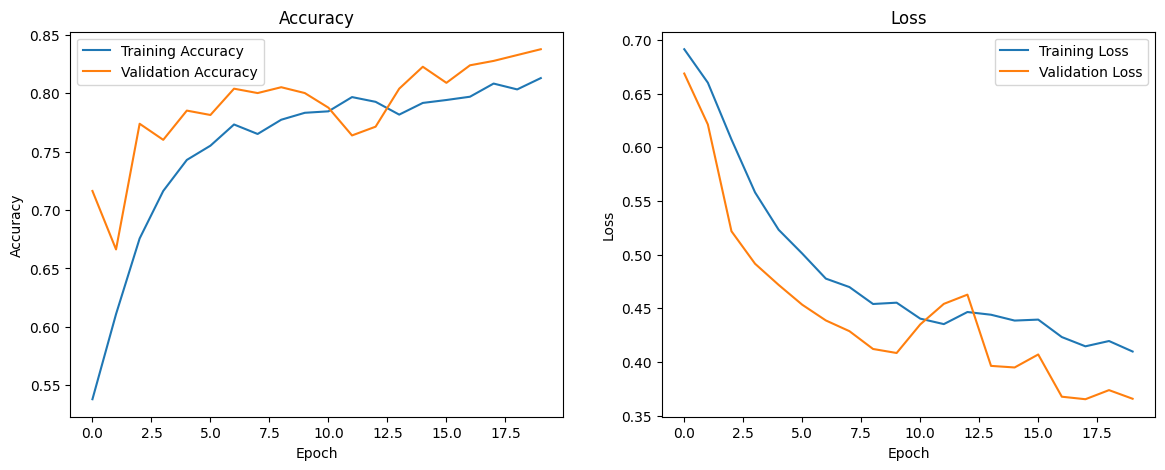

In [36]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()